# Eye Disease Classification
## Data Preprocessing and Cleansing

This notebook performs data exploration, cleansing, and normalization for the eye disease image dataset. The goal is to prepare a clean dataset for future model training while preserving the original dataset.

The following preprocessing steps are performed:

1. Dataset structure verification
2. Image count per class
3. Removal of corrupted images
4. Checking image size consistency
5. Resizing images to a uniform dimension
6. Detecting duplicate images
7. Pixel normalization
8. Image format verification
9. Empty file check
10. Random image visualization
11. Image dimension statistics

The original dataset remains untouched. A cleaned dataset is generated separately.

In [1]:
import os
import shutil
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import imagehash

## The dataset is organized into training and validation folders with class-based subdirectories.

In [2]:
# Artifacts (art): data, graphs, models, etc. From ipynb/ use ../art
ART_ROOT = os.path.join("..", "art")
if not os.path.isdir(ART_ROOT):
    raise FileNotFoundError(
        f"Artifacts folder not found: {os.path.abspath(ART_ROOT)}\n"
        "Create it at project root (e.g. art/raw/train, art/raw/validate)."
    )

# art/raw: train and validate (input)
raw_train_dir = os.path.join(ART_ROOT, "raw", "train")
raw_val_dir = os.path.join(ART_ROOT, "raw", "validate")

# art/clean: train and validate (output)
clean_root = os.path.join(ART_ROOT, "clean")
clean_train_dir = os.path.join(ART_ROOT, "clean", "train")
clean_val_dir = os.path.join(ART_ROOT, "clean", "validate")

os.makedirs(clean_train_dir, exist_ok=True)
os.makedirs(clean_val_dir, exist_ok=True)

### Verifying that the dataset directory contains the expected folder structure and class labels.

In [3]:
print("Train Classes:", os.listdir(raw_train_dir))
print("Validation Classes:", os.listdir(raw_val_dir))

Train Classes: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
Validation Classes: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


### Removal of macOS System Files (.DS_Store)

In [4]:
def remove_ds_store(root_dir):
    removed = 0
    for root, dirs, files in os.walk(root_dir):
        for file in files:
            if file == ".DS_Store":
                path = os.path.join(root, file)
                os.remove(path)
                removed += 1
    return removed


removed_train = remove_ds_store(raw_train_dir)
removed_val = remove_ds_store(raw_val_dir)

print(f".DS_Store removed from Train: {removed_train}")
print(f".DS_Store removed from Val: {removed_val}")

.DS_Store removed from Train: 0
.DS_Store removed from Val: 0


### Understanding the number of images per class helps identify class imbalance.

Train Distribution: {'cataract': 1018, 'diabetic_retinopathy': 1086, 'glaucoma': 987, 'normal': 1054}
Validation Distribution: {'cataract': 20, 'diabetic_retinopathy': 13, 'glaucoma': 20, 'normal': 20}


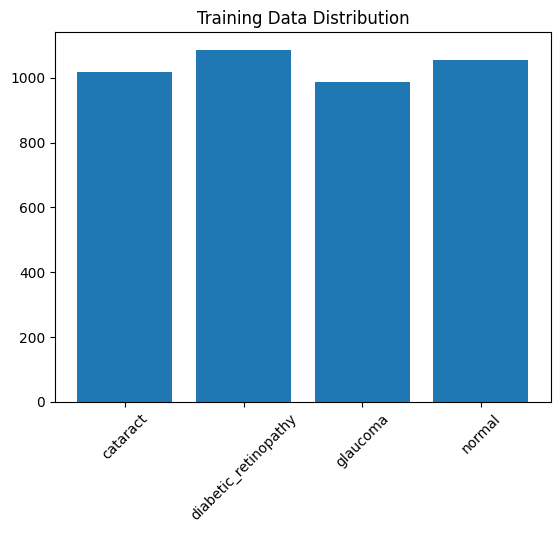

In [5]:
def count_images(directory):
    counts = {}
    for cls in os.listdir(directory):
        cls_path = os.path.join(directory, cls)
        counts[cls] = len(os.listdir(cls_path))
    return counts

train_counts = count_images(raw_train_dir)
val_counts = count_images(raw_val_dir)

print("Train Distribution:", train_counts)
print("Validation Distribution:", val_counts)

plt.bar(train_counts.keys(), train_counts.values())
plt.title("Training Data Distribution")
plt.xticks(rotation=45)
plt.show()

### Verifying that images are stored in valid formats such as JPG, JPEG, or PNG.

In [6]:
formats = {}

for root, dirs, files in os.walk(raw_train_dir):
    for file in files:
        ext = file.split(".")[-1].lower()
        formats[ext] = formats.get(ext,0) + 1

formats

{'jpg': 2864, 'png': 195, 'jpeg': 1086}

### Detecting images that have zero file size which indicates incomplete or corrupted files.

In [7]:
empty_files = []

for root, dirs, files in os.walk(raw_train_dir):
    for file in files:
        path = os.path.join(root,file)
        if os.path.getsize(path) == 0:
            empty_files.append(path)

print("Empty files:", len(empty_files))

Empty files: 0


### Corrupted images that cannot be opened are excluded. Clean images are copied to a new dataset folder.

In [8]:
def clean_and_copy(src_dir, dst_dir):

    for cls in os.listdir(src_dir):

        src_cls = os.path.join(src_dir, cls)
        dst_cls = os.path.join(dst_dir, cls)

        os.makedirs(dst_cls, exist_ok=True)

        for file in tqdm(os.listdir(src_cls)):

            src_file = os.path.join(src_cls,file)
            dst_file = os.path.join(dst_cls,file)

            try:
                img = Image.open(src_file)
                img.verify()

                shutil.copy(src_file, dst_file)

            except:
                continue

clean_and_copy(raw_train_dir, clean_train_dir)
clean_and_copy(raw_val_dir, clean_val_dir)

100%|███████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 125.29it/s]


### Image width and height distribution analysis across the dataset.

In [9]:
widths = []
heights = []
## COMMENTS ## Do by class; and need bar graph
print(clean_train_dir)
for root, dirs, files in os.walk(clean_train_dir):

    for file in files:

        path = os.path.join(root,file)
        img = cv2.imread(path)

        h,w,_ = img.shape

        widths.append(w)
        heights.append(h)

print("Min Width:",min(widths))
print("Max Width:",max(widths))
print("Avg Width:",np.mean(widths))

print("Min Height:",min(heights))
print("Max Height:",max(heights))
print("Avg Height:",np.mean(heights))

..\art\clean\train
Min Width: 256
Max Width: 2592
Avg Width: 531.8137515078407
Min Height: 256
Max Height: 1728
Avg Height: 492.0627261761158


### Image Size Consistency Check

In [10]:
unique_sizes = set()

for root, dirs, files in os.walk(clean_train_dir):

    for file in files:

        path = os.path.join(root,file)
        img = cv2.imread(path)

        unique_sizes.add(img.shape)

len(unique_sizes)

5

### Duplicate images can bias model training and must be detected.

In [11]:
hashes = {}
duplicates = [] 
## COMMENTS ## find issues with image; discussed 9 issues with image or more blue, odd aspect ratio, dark etc.. refere brain_tumour.ipynb
## near duplicate and display image of those
for root, dirs, files in os.walk(clean_train_dir):

    for file in files:

        path = os.path.join(root,file)

        img = Image.open(path)
        h = imagehash.average_hash(img)

        if h in hashes:
            duplicates.append(path)
        else:
            hashes[h] = path

print("Duplicates found:", len(duplicates))

Duplicates found: 1109


### Images are resized to 224 × 224 to maintain consistency for CNN models.

In [12]:
IMG_SIZE = 224

def resize_images(directory):

    for root, dirs, files in os.walk(directory):

        for file in files:

            path = os.path.join(root,file)

            img = cv2.imread(path)

            resized = cv2.resize(img,(IMG_SIZE,IMG_SIZE))

            cv2.imwrite(path,resized)

resize_images(clean_train_dir)
resize_images(clean_val_dir)

### Pixel values originally range from 0 to 255. Normalization scales them to the range 0 to 1 to improve model convergence.

In [13]:
img = cv2.imread(list(Path(clean_train_dir).rglob("*.*"))[0].as_posix())
## COMMENTS ##  Happened during modeling; shuould happen while modeling in parameters on training (not validate or test)
normalized = img / 255.0

print("Original Range:",img.min(),img.max())
print("Normalized Range:",normalized.min(),normalized.max())

Original Range: 0 147
Normalized Range: 0.0 0.5764705882352941


### Visual inspection to confirm dataset integrity after preprocessing.

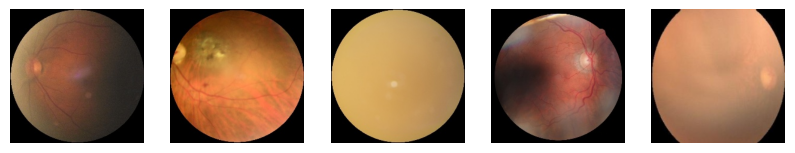

In [14]:
import random

sample_paths = list(Path(clean_train_dir).rglob("*.*"))

plt.figure(figsize=(10,5))

for i in range(5):

    img_path = random.choice(sample_paths)

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

### Final Dataset Statistics

Total Training Images: 4145
Total Validation Images: 73
Total Images: 4218


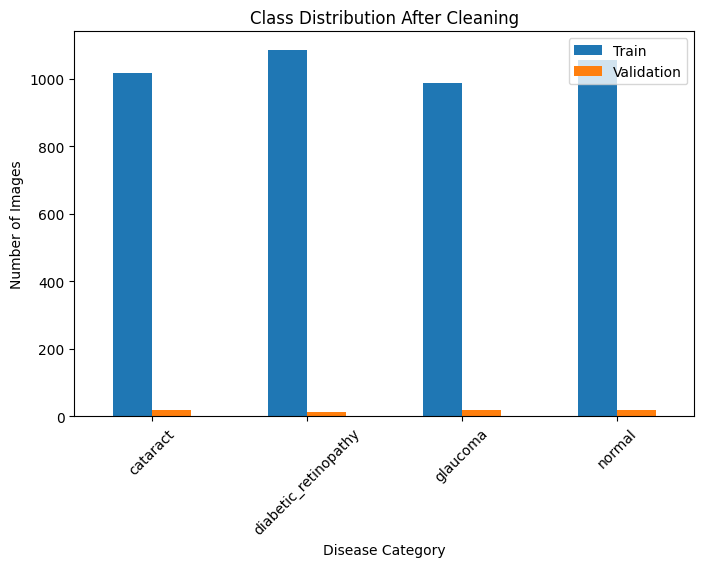

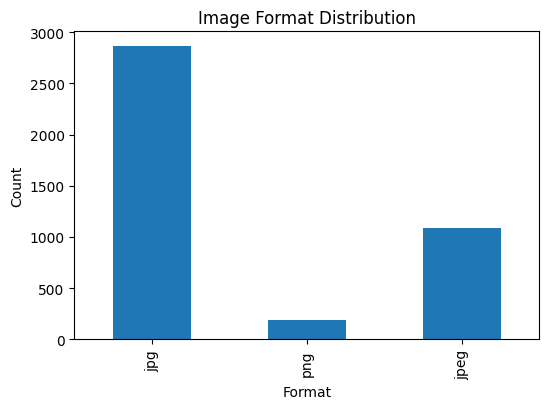

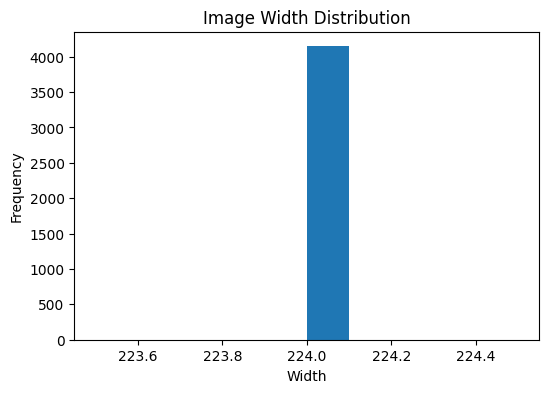

Original Range: 0 - 147
Normalized Range: 0.0 - 0.5764705882352941


In [15]:
# Total images
# ============
train_total = sum(len(files) for _,_,files in os.walk(clean_train_dir))
val_total = sum(len(files) for _,_,files in os.walk(clean_val_dir))

print("Total Training Images:", train_total)
print("Total Validation Images:", val_total)
print("Total Images:", train_total + val_total)

## COMMENTS ## Agument train images not with test images. Train (train 0.6 and test 0.4 ; validate 0)

# Class Distribution Table
# =========================
train_counts = count_images(clean_train_dir)
val_counts = count_images(clean_val_dir)

df_counts = pd.DataFrame({
    "Train": train_counts,
    "Validation": val_counts
})

df_counts

# Class Distribution Graph
# ========================
df_counts.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Class Distribution After Cleaning")
plt.ylabel("Number of Images")
plt.xlabel("Disease Category")
plt.xticks(rotation=45)
plt.show()

# Image Format Distribution
# =========================
format_counts = {}

for root, dirs, files in os.walk(clean_train_dir):
    for file in files:
        ext = file.split(".")[-1].lower()
        format_counts[ext] = format_counts.get(ext,0) + 1

df_formats = pd.DataFrame.from_dict(
    format_counts,
    orient="index",
    columns=["Count"]
)

df_formats

# Format Distribution Graph
# ========================
df_formats.plot(
    kind="bar",
    legend=False,
    figsize=(6,4)
)

plt.title("Image Format Distribution")
plt.ylabel("Count")
plt.xlabel("Format")
plt.show()

# Image Dimension Statistics
# ==========================
widths = []
heights = []

for root, dirs, files in os.walk(clean_train_dir):

    for file in files:

        img = cv2.imread(os.path.join(root,file))
        h,w,_ = img.shape

        heights.append(h)
        widths.append(w)

df_dimensions = pd.DataFrame({
    "Width": widths,
    "Height": heights
})

df_dimensions.describe()

# Image Dimension Distribution
# ============================
plt.figure(figsize=(6,4))

plt.hist(widths, bins=10)
plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")

plt.show()

# Pixel Normalization Verification
# ================================
sample = cv2.imread(str(list(Path(clean_train_dir).rglob("*.*"))[0]))

normalized = sample / 255.0

print("Original Range:", sample.min(), "-", sample.max())
print("Normalized Range:", normalized.min(), "-", normalized.max())

In [ ]:
# COMMENT ### Heigh, aspect ratio, 
# Grey scale; during augmentation zoom, brighter

#glaucoma/_107_7535300.jpg take help LLM